# UT2 · 4 — Reto integrador, primer vistazo a Scikit-learn y adelanto del proyecto

Cuarto y último cuaderno de la Unidad 2. Junta lo practicado en los tres anteriores (NumPy, Pandas y Matplotlib) en un solo flujo: cargar → limpiar → visualizar → un primer `fit`/`predict`. Cierra con un adelanto del proyecto en equipo que arranca en la semana 7.

Es autocontenido: regenera su propio dataset de jugadores.

In [1]:
# Si alguna librería falta, descomenta e instala:
# !pip install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

plataformas = ["PC", "Consola"]
n = 40

df = pd.DataFrame({
    "jugador_id": range(1, n + 1),
    "plataforma": np.random.choice(plataformas, size=n),
    "horas_jugadas": np.round(np.random.normal(6, 2, size=n), 1),
    "puntuacion": np.round(np.random.normal(6.2, 1.8, size=n), 1),
})
df.loc[[3, 15, 27], "puntuacion"] = np.nan
df.loc[[5, 22], "horas_jugadas"] = np.nan
df = pd.concat([df, df.iloc[[0, 1]]], ignore_index=True)
df["puntuacion"] = df["puntuacion"].clip(0, 10)

df_limpio = df.drop_duplicates().copy()
df_limpio["puntuacion"] = df_limpio["puntuacion"].fillna(df_limpio["puntuacion"].mean())
df_limpio["horas_jugadas"] = df_limpio["horas_jugadas"].fillna(df_limpio["horas_jugadas"].mean())
df_codificado = pd.get_dummies(df_limpio, columns=["plataforma"])

print("Librerías cargadas y dataset listo:", df_limpio.shape)

Librerías cargadas y dataset listo: (40, 4)


## 1 · Reto integrador

Encadena tú solo/a los tres pasos: carga (ya la tenemos en `df`), limpieza (ya la tenemos en `df_limpio`/`df_codificado`) y una gráfica que responda a una pregunta concreta. Completa las líneas marcadas con `# TODO`.

Puntuación media en Consola: 6.01


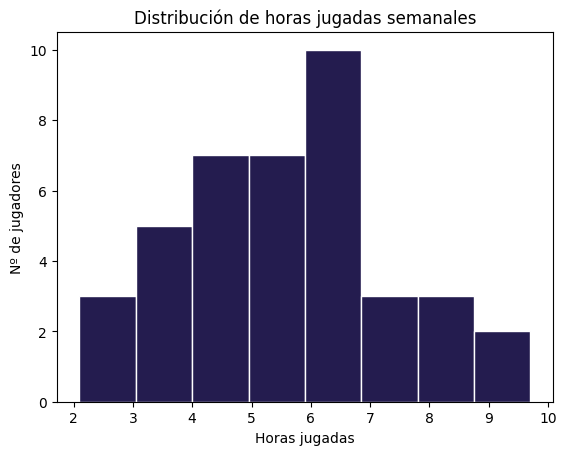

In [2]:
# TODO: ¿cuál es la puntuación media en Consola, una vez limpiado el dataset?
puntuacion_media_consola = df_codificado[df_codificado["plataforma_Consola"] == True]["puntuacion"].mean()
print(f"Puntuación media en Consola: {round(puntuacion_media_consola, 2)}")

# TODO: dibuja un histograma solo de las horas jugadas
plt.hist(df_limpio["horas_jugadas"], bins=8, color="#241C4F", edgecolor="white")
plt.title("Distribución de horas jugadas semanales")
plt.xlabel("Horas jugadas")
plt.ylabel("Nº de jugadores")
plt.show()

## 2 · Primer vistazo a Scikit-learn

Todavía no hemos visto la teoría (eso llega en UT3), pero sí podemos ver el patrón de código que vas a repetir con casi cualquier modelo: `fit()` para entrenar, `predict()` para predecir.

### Separar en entrenamiento y prueba

Antes de entrenar, reservamos una parte de los datos ("test") que el modelo no verá durante el entrenamiento — así podemos comprobar si de verdad generaliza.

In [3]:
from sklearn.model_selection import train_test_split

X = df_limpio[["horas_jugadas"]]
y = df_limpio["puntuacion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Filas de entrenamiento:", len(X_train), " · Filas de prueba:", len(X_test))

Filas de entrenamiento: 32  · Filas de prueba: 8


In [4]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)                    # entrena solo con los datos de entrenamiento

horas_nuevas = pd.DataFrame({"horas_jugadas": [2, 6, 10]})
predicciones = modelo.predict(horas_nuevas)

for h, p in zip(horas_nuevas["horas_jugadas"], predicciones):
    print(f"Con {h}h jugadas, el modelo predice una puntuación de {round(p, 2)}")

print("R² sobre los datos de prueba (no vistos en el entrenamiento):", round(modelo.score(X_test, y_test), 3))

Con 2h jugadas, el modelo predice una puntuación de 6.48
Con 6h jugadas, el modelo predice una puntuación de 5.8
Con 10h jugadas, el modelo predice una puntuación de 5.12
R² sobre los datos de prueba (no vistos en el entrenamiento): -0.305


No te preocupes si `fit`/`predict` todavía no te dice mucho — es exactamente el patrón que vamos a diseccionar desde cero al empezar UT3 (Aprendizaje supervisado). Aquí solo queríamos que el código no te resultara extraño el primer día.

## 3 · Adelanto del proyecto: de texto a una tabla de características

En la semana 7 arranca el proyecto en equipo, y uno de los dos que puedes elegir es **"¿Lo escribió una IA?"** — un clasificador de texto humano vs. generado por IA. Antes de entrenar nada (eso llega en UT3), el primer paso es el mismo que acabas de practicar con `jugadores`: convertir texto libre en filas y columnas de números.

Aviso: el dataset de abajo son diez sinopsis breves **inventadas** para practicar la técnica, con una etiqueta de origen puesta a propósito — no es un dataset real de detección de IA.

In [5]:
textos = [
    {"titulo": "Stranger Things",  "sinopsis": "Un grupo de críos de un pueblo perdido se topa con monstruos, portales y unos militares muy turbios. Te enganchas por la nostalgia ochentera, no te voy a mentir.", "origen": "humano"},
    {"titulo": "El Juego del Calamar", "sinopsis": "Gente hasta arriba de deudas juega a juegos infantiles... por su vida. Es durísima y a la vez no puedes dejar de verla.", "origen": "humano"},
    {"titulo": "La Casa de Papel", "sinopsis": "Un atraco imposible, una banda con nombres de ciudades y el Profesor liándola parda desde el primer minuto. Viciante total.", "origen": "humano"},
    {"titulo": "Wednesday",        "sinopsis": "La hija de los Addams en un instituto para rarones, resolviendo un misterio con esa cara de póker que ya es un meme.", "origen": "humano"},
    {"titulo": "The Bear",         "sinopsis": "Un cocinero de restaurante top vuelve al bareto de su familia hecho un caos, con la cocina ardiendo literal y figuradamente.", "origen": "humano"},
    {"titulo": "Bridgerton",       "sinopsis": "Serie ambientada en la alta sociedad londinense que explora las relaciones amorosas, las expectativas familiares y las normas sociales de la época.", "origen": "IA"},
    {"titulo": "House of the Dragon", "sinopsis": "Producción de fantasía que narra los conflictos de poder dentro de una familia real, abordando temas de sucesión, lealtad y estrategia política.", "origen": "IA"},
    {"titulo": "Only Murders in the Building", "sinopsis": "Comedia de misterio centrada en tres vecinos de un edificio que deciden investigar un crimen, combinando suspense con un tono ligero y humorístico.", "origen": "IA"},
    {"titulo": "Ted Lasso",        "sinopsis": "Serie de comedia que sigue a un entrenador de fútbol trasladado a Inglaterra, centrada en el optimismo, el trabajo en equipo y el desarrollo personal.", "origen": "IA"},
    {"titulo": "Rick and Morty",   "sinopsis": "Serie de animación centrada en las aventuras interdimensionales de un científico excéntrico y su nieto, combinando humor absurdo con reflexiones sobre la ciencia.", "origen": "IA"},
]

df_textos = pd.DataFrame(textos)
df_textos.head()

,titulo,sinopsis,origen
0,Stranger Things,Un grupo de críos de un pueblo perdido se topa...,humano
1,El Juego del Calamar,Gente hasta arriba de deudas juega a juegos in...,humano
2,La Casa de Papel,"Un atraco imposible, una banda con nombres de ...",humano
3,Wednesday,La hija de los Addams en un instituto para rar...,humano
4,The Bear,Un cocinero de restaurante top vuelve al baret...,humano


### Ingeniería de características

Las mismas herramientas de siempre — funciones de texto de Python aplicadas columna a columna con Pandas.

In [6]:
df_textos["num_caracteres"] = df_textos["sinopsis"].str.len()
df_textos["num_palabras"] = df_textos["sinopsis"].str.split().str.len()
df_textos["num_exclamaciones"] = df_textos["sinopsis"].str.count("!")

# diversidad léxica: palabras distintas / total de palabras
df_textos["diversidad_lexica"] = df_textos["sinopsis"].apply(
    lambda texto: len(set(texto.lower().split())) / len(texto.split())
)

df_textos[["titulo", "num_caracteres", "num_palabras", "num_exclamaciones", "diversidad_lexica"]]

,titulo,num_caracteres,num_palabras,num_exclamaciones,diversidad_lexica
0,Stranger Things,161,29,0,0.896552
1,El Juego del Calamar,119,23,0,0.913043
2,La Casa de Papel,123,20,0,0.950000
3,Wednesday,116,23,0,0.869565
4,The Bear,124,21,0,0.904762
5,Bridgerton,147,22,0,0.863636
6,House of the Dragon,144,22,0,0.863636
7,Only Murders in the Building,147,23,0,0.869565
8,Ted Lasso,150,25,0,0.800000
9,Rick and Morty,162,23,0,0.956522


### ¿Hay diferencia entre "humano" e "IA" en este ejemplo?

In [7]:
df_textos.groupby("origen")[["num_palabras", "num_exclamaciones", "diversidad_lexica"]].mean()
# con solo 10 filas esto es solo para practicar el proceso, no una conclusión real

,num_palabras,num_exclamaciones,diversidad_lexica
origen,,,
IA,23.0,0.0,0.870672
humano,23.2,0.0,0.906784


**Reto rápido:** añade una característica nueva propia (por ejemplo, longitud media de palabra, o número de comas) y comprueba si separa mejor o peor los dos grupos que `diversidad_lexica`.

In [8]:
# Solución de ejemplo: longitud media de palabra
df_textos["longitud_media_palabra"] = df_textos["sinopsis"].str.split().apply(
    lambda palabras: sum(len(p) for p in palabras) / len(palabras)
)
df_textos.groupby("origen")["longitud_media_palabra"].mean()

origen
IA        5.575984
humano    4.608587
Name: longitud_media_palabra, dtype: float64

No hemos entrenado ningún modelo todavía — eso es justo lo que veremos en UT3 con `train_test_split` + `fit`/`predict`, aplicado a una tabla de características como esta en vez de a las frases sueltas.

---
**Resumen de la Unidad 2 (los 4 cuadernos):** arrays y vectorización con NumPy · carga, limpieza y combinación de datos con Pandas · visualización con Matplotlib · un primer `fit`/`predict` con Scikit-learn · el primer paso del proyecto en equipo: convertir texto en una tabla de números.